In [4]:
import os
import boto3
import json
import pandas as pd
import matplotlib.pyplot as plt
import awswrangler as wr
from sqlalchemy import create_engine, text

plt.style.use('ggplot')

# Credenciales desde Secrets Manager
client = boto3.client("secretsmanager", region_name="us-east-1")
secret = client.get_secret_value(SecretId="itam/rds/flights/credentials")
creds = json.loads(secret["SecretString"])

# Conexión a Read Replica
REPLICA_HOST = "itam-flights-replica-448591726855.ci7osqgw4ccz.us-east-1.rds.amazonaws.com"
url = f"postgresql+psycopg2://{creds['username']}:{creds['password']}@{REPLICA_HOST}:{creds['port']}/{creds['dbname']}"
engine = create_engine(url, echo=False)
print("Conexión exitosa a Read Replica")

Conexión exitosa a Read Replica


,origin_airport,destination_airport,total_flights
0,LAX,JFK,1218
1,JFK,LAX,1217
2,SFO,LAX,1186
3,LAX,SFO,1172
4,LAS,LAX,1018
5,LAX,LAS,987
6,LGA,ORD,917
7,ORD,LGA,908
8,HNL,OGG,874
9,OGG,HNL,873


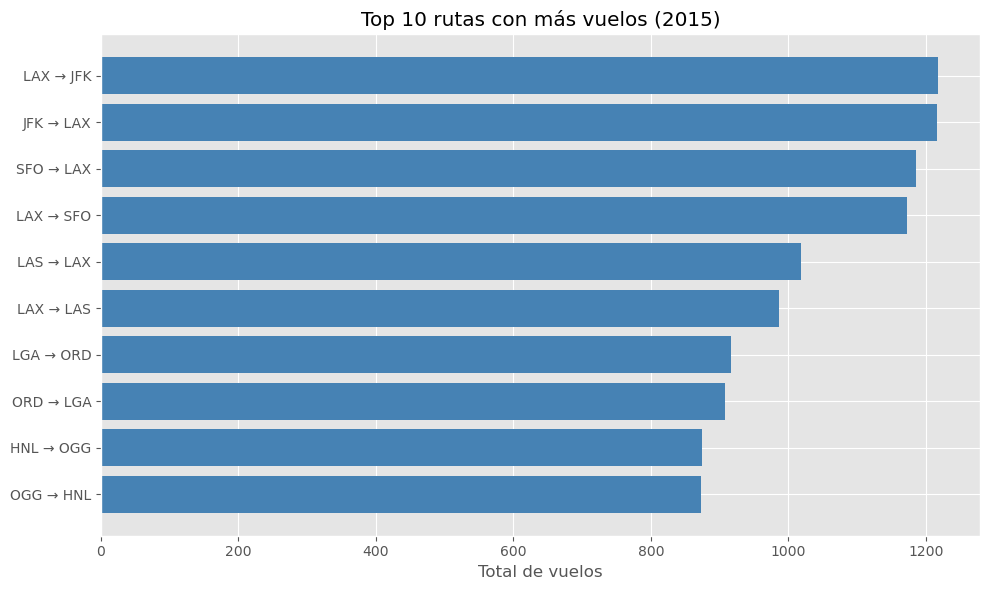

In [5]:
sql_p1 = """
SELECT origin_airport, destination_airport, COUNT(*) AS total_flights
FROM flights
GROUP BY origin_airport, destination_airport
ORDER BY total_flights DESC
LIMIT 10;
"""
df_p1 = pd.read_sql(sql_p1, engine)
display(df_p1)

df_p1["ruta"] = df_p1["origin_airport"] + " → " + df_p1["destination_airport"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_p1["ruta"], df_p1["total_flights"], color="steelblue")
ax.set_xlabel("Total de vuelos")
ax.set_title("Top 10 rutas con más vuelos (2015)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,airline,total_flights,total_cancelled,pct_cancelled
0,MQ,31896,3136,9.83
1,B6,23062,1479,6.41
2,EV,52965,2523,4.76
3,US,35591,1268,3.56
4,UA,40873,1424,3.48


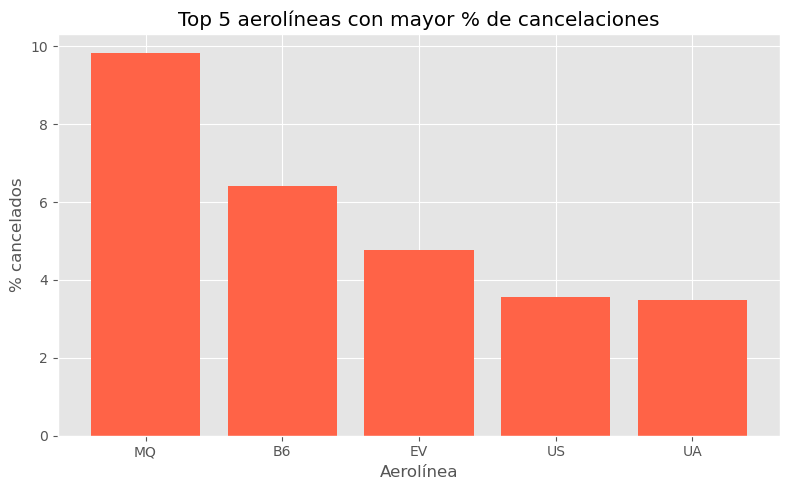

In [6]:
sql_p2 = """
SELECT airline,
       COUNT(*) AS total_flights,
       SUM(cancelled) AS total_cancelled,
       ROUND(SUM(cancelled) * 100.0 / COUNT(*), 2) AS pct_cancelled
FROM flights
GROUP BY airline
ORDER BY pct_cancelled DESC
LIMIT 5;
"""
df_p2 = pd.read_sql(sql_p2, engine)
display(df_p2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_p2["airline"], df_p2["pct_cancelled"], color="tomato")
ax.set_xlabel("Aerolínea")
ax.set_ylabel("% cancelados")
ax.set_title("Top 5 aerolíneas con mayor % de cancelaciones")
plt.tight_layout()
plt.show()

,cancellation_reason,total,causa
0,B,10630,B - Weather
1,A,3230,A - Carrier
2,C,2962,C - NAS
3,D,2,D - Security


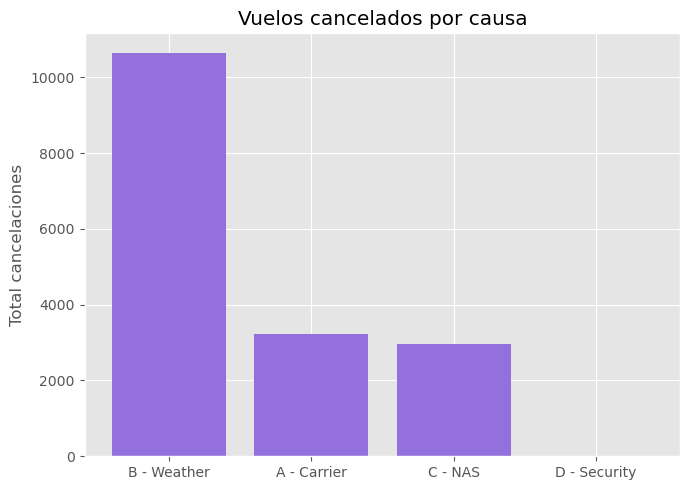

In [7]:
sql_p3 = """
SELECT cancellation_reason, COUNT(*) AS total
FROM flights
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason
ORDER BY total DESC;
"""
df_p3 = pd.read_sql(sql_p3, engine)
df_p3["causa"] = df_p3["cancellation_reason"].map({
    "A": "A - Carrier", "B": "B - Weather",
    "C": "C - NAS",     "D": "D - Security"
})
display(df_p3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(df_p3["causa"], df_p3["total"], color="mediumpurple")
ax.set_title("Vuelos cancelados por causa")
ax.set_ylabel("Total cancelaciones")
plt.tight_layout()
plt.show()

,month,avg_departure_delay
0,1,32.57
1,2,42.31


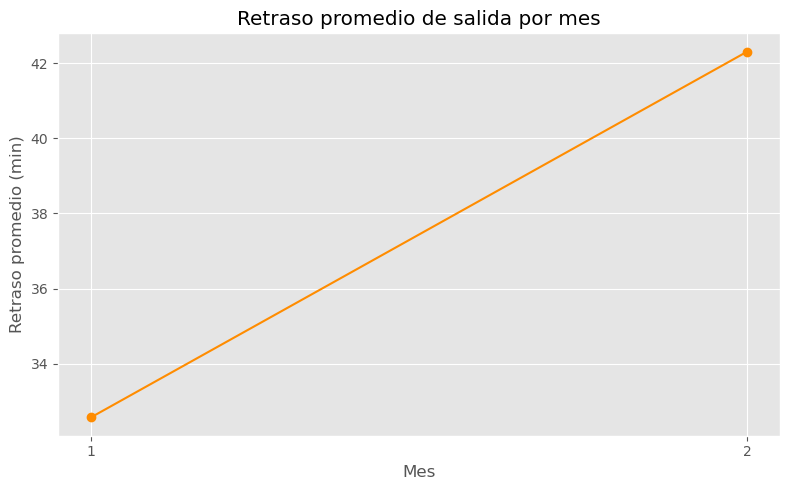

In [8]:
sql_p4 = """
SELECT month,
       ROUND(AVG(departure_delay)::numeric, 2) AS avg_departure_delay
FROM flights
WHERE cancelled = 0 AND departure_delay > 0
GROUP BY month
ORDER BY month;
"""
df_p4 = pd.read_sql(sql_p4, engine)
display(df_p4)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_p4["month"], df_p4["avg_departure_delay"], marker="o", color="darkorange")
ax.set_xlabel("Mes")
ax.set_ylabel("Retraso promedio (min)")
ax.set_title("Retraso promedio de salida por mes")
ax.set_xticks(df_p4["month"])
plt.tight_layout()
plt.show()

,origin_airport,total_weather_delay_minutes
0,ABI,NaN
1,ABQ,NaN
2,ABR,NaN
3,ABY,NaN
4,ACT,NaN
5,ACV,NaN
6,ACY,NaN
7,ADK,NaN
8,ADQ,NaN
9,ABE,NaN


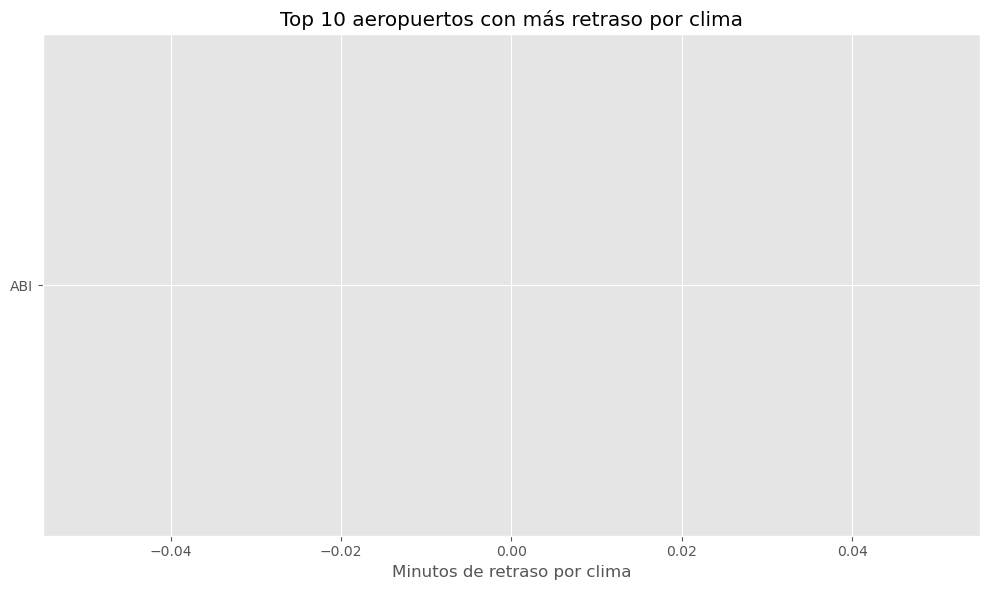

In [9]:
sql_p5 = """
SELECT origin_airport,
       SUM(weather_delay) AS total_weather_delay_minutes
FROM flights
WHERE weather_delay > 0
GROUP BY origin_airport
ORDER BY total_weather_delay_minutes DESC
LIMIT 10;
"""
df_p5 = pd.read_sql(sql_p5, engine)
display(df_p5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_p5["origin_airport"], df_p5["total_weather_delay_minutes"], color="cadetblue")
ax.set_xlabel("Minutos de retraso por clima")
ax.set_title("Top 10 aeropuertos con más retraso por clima")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,airline,origin_airport,destination_airport,arrival_delay,rnk
0,AA,DEN,MIA,NaN,1
1,AA,ORD,DCA,NaN,1
2,AA,OMA,DFW,NaN,1
3,AA,DFW,BDL,NaN,1
4,AA,LAX,HNL,NaN,1
...,...,...,...,...,...
1119,WN,DEN,SMF,NaN,1
1120,WN,DEN,DAL,NaN,1
1121,WN,LAS,PDX,NaN,1
1122,WN,JAX,HOU,NaN,1


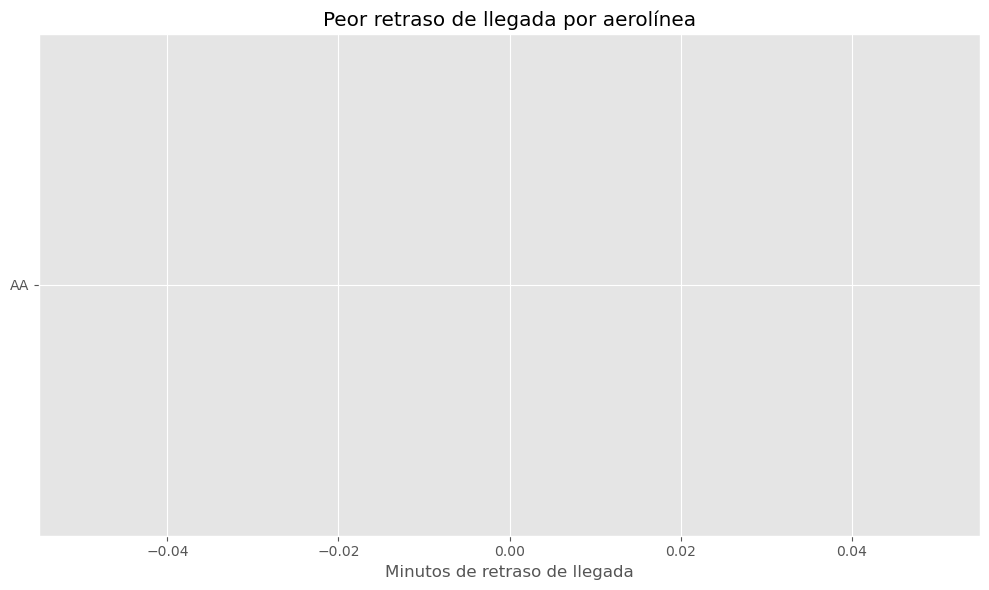

In [10]:
sql_w1 = """
SELECT airline, origin_airport, destination_airport, arrival_delay, rnk
FROM (
    SELECT airline, origin_airport, destination_airport, arrival_delay,
           RANK() OVER (PARTITION BY airline ORDER BY arrival_delay DESC NULLS LAST) AS rnk
    FROM flights
    WHERE cancelled = 0
) ranked
WHERE rnk = 1
ORDER BY airline;
"""
df_w1 = pd.read_sql(sql_w1, engine)
display(df_w1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_w1["airline"], df_w1["arrival_delay"], color="firebrick")
ax.set_xlabel("Minutos de retraso de llegada")
ax.set_title("Peor retraso de llegada por aerolínea")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

2026-04-15 18:08:29,187	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409956352 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.85gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-15 18:08:30,487	INFO worker.py:1852 -- Started a local Ray instance.


,month,total_flights,prev_flights,diff_abs,diff_pct
0,1,469968,<NA>,<NA>,<NA>
1,2,429191,469968,-40777,-8.68
2,3,504312,429191,75121,17.5
3,4,485151,504312,-19161,-3.8
4,5,496993,485151,11842,2.44
5,6,503897,496993,6904,1.39
6,7,520718,503897,16821,3.34
7,8,510536,520718,-10182,-1.96
8,9,464946,510536,-45590,-8.93
9,10,486165,464946,21219,4.56


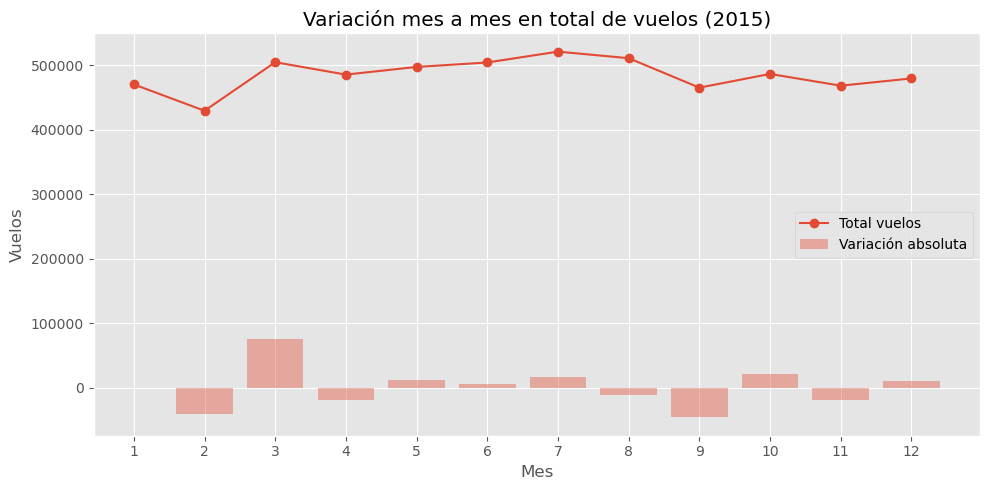

In [11]:
BUCKET = "flight-data-manuel"

df_monthly = wr.athena.read_sql_query(
    sql="SELECT month, SUM(total_flights) AS total_flights FROM flights_silver.flights_monthly GROUP BY month ORDER BY month",
    database="flights_silver",
    s3_output=f"s3://{BUCKET}/athena-results/",
)

df_monthly["prev_flights"] = df_monthly["total_flights"].shift(1)
df_monthly["diff_abs"]     = df_monthly["total_flights"] - df_monthly["prev_flights"]
df_monthly["diff_pct"]     = (df_monthly["diff_abs"] / df_monthly["prev_flights"] * 100).round(2)
display(df_monthly)

# Separar el df sin el primer mes (que tiene NaN en diff_abs)
df_plot = df_monthly.dropna(subset=["diff_abs"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_monthly["month"], df_monthly["total_flights"], marker="o", label="Total vuelos")
ax.bar(df_plot["month"], df_plot["diff_abs"], alpha=0.4, label="Variación absoluta")
ax.set_xlabel("Mes")
ax.set_ylabel("Vuelos")
ax.set_title("Variación mes a mes en total de vuelos (2015)")
ax.set_xticks(df_monthly["month"])
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
sql_w3 = """
SELECT ROW_NUMBER() OVER (
           PARTITION BY year, month, day, origin_airport
           ORDER BY departure_delay ASC
       ) AS row_num,
       airline, destination_airport, departure_delay
FROM flights
WHERE year = 2015 AND month = 1 AND day = 1
  AND origin_airport = 'LAX'
LIMIT 5;
"""
df_w3 = pd.read_sql(sql_w3, engine)
display(df_w3)

,row_num,airline,destination_airport,departure_delay
0,1,OO,SEA,-13.0
1,2,OO,MRY,-13.0
2,3,UA,BOS,-11.0
3,4,OO,OAK,-11.0
4,5,OO,TUS,-10.0


In [13]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# Lee datos desde Gold en Athena
df_reg = wr.athena.read_sql_query(
    sql="""
    SELECT arrival_delay, departure_delay, distance,
           air_system_delay, airline_delay, weather_delay,
           late_aircraft_delay, security_delay
    FROM flights_gold.vuelos_analitica
    WHERE cancelled = 0
    AND arrival_delay IS NOT NULL
    """,
    database="flights_gold",
    s3_output=f"s3://{BUCKET}/athena-results/",
)

print(f"Filas cargadas: {len(df_reg):,}")
df_reg.head()

Filas cargadas: 5,714,008


,arrival_delay,departure_delay,distance,air_system_delay,airline_delay,weather_delay,late_aircraft_delay,security_delay
0,-18.0,-9.0,147,NaN,NaN,NaN,NaN,NaN
1,-25.0,-15.0,626,NaN,NaN,NaN,NaN,NaN
2,-31.0,-5.0,455,NaN,NaN,NaN,NaN,NaN
3,-14.0,-9.0,201,NaN,NaN,NaN,NaN,NaN
4,-8.0,0.0,854,NaN,NaN,NaN,NaN,NaN


In [14]:
features = [
    "departure_delay", "distance",
    "air_system_delay", "airline_delay",
    "weather_delay", "late_aircraft_delay", "security_delay"
]

# Elimina filas con NaN en cualquier feature
df_model = df_reg[features + ["arrival_delay"]].dropna()

X = df_model[features]
y = df_model["arrival_delay"]

# Agrega constante para el intercepto
X_const = sm.add_constant(X)

print(f"Observaciones para el modelo: {len(df_model):,}")

Observaciones para el modelo: 1,063,439


In [15]:
# Fuerza tipos numéricos y elimina NaN
for col in features + ["arrival_delay"]:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model = df_model.dropna()

X = df_model[features]
y = df_model["arrival_delay"]

X_const = sm.add_constant(X)

print(f"Observaciones limpias: {len(df_model):,}")

Observaciones limpias: 1,063,439


In [16]:
import numpy as np

# Revisa qué hay en cada columna
for col in X_const.columns:
    try:
        np.asarray(X_const[col], dtype=float)
        print(f"✓ {col}: OK")
    except Exception as e:
        print(f"✗ {col}: {e}")
        print(f"  Valores únicos problemáticos: {X_const[col][pd.to_numeric(X_const[col], errors='coerce').isna()].unique()[:5]}")

✓ const: OK
✓ departure_delay: OK
✓ distance: OK
✓ air_system_delay: OK
✓ airline_delay: OK
✓ weather_delay: OK
✓ late_aircraft_delay: OK
✓ security_delay: OK


In [17]:
X_np = X_const.to_numpy(dtype=float)
y_np = y.to_numpy(dtype=float)

model = sm.OLS(y_np, X_np).fit()
model.feature_names = X_const.columns.tolist()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.184e+32
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:09:06   Log-Likelihood:             2.7660e+07
No. Observations:             1063439   AIC:                        -5.532e+07
Df Residuals:                 1063431   BIC:                        -5.532e+07
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.292e-12   2.34e-15    553.186      0.0

In [18]:
y_pred = model.predict(X_const)
r2   = model.rsquared
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.2f} minutos")

R²:   1.0000
RMSE: 0.00 minutos


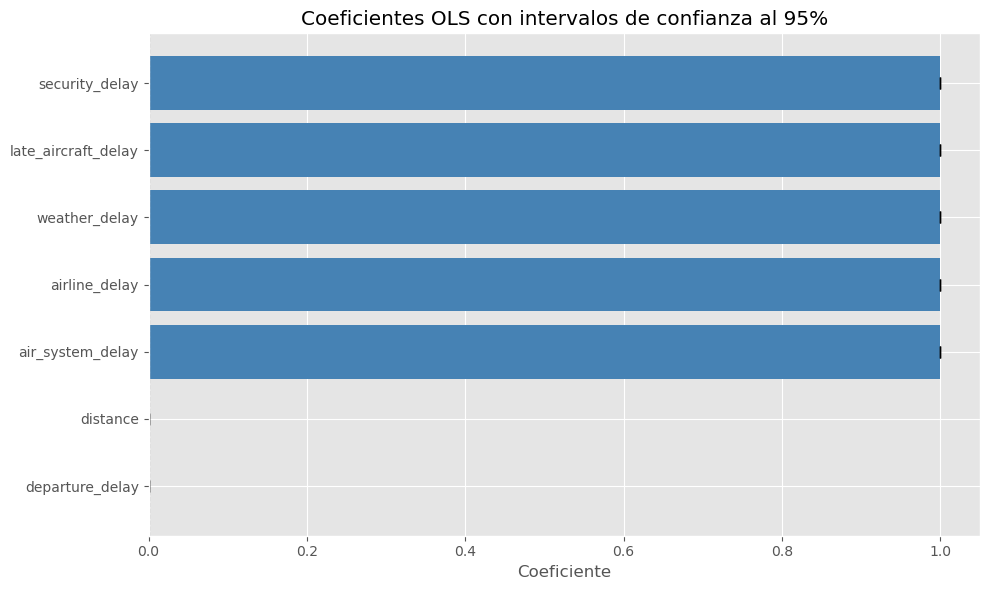

In [20]:
feature_names = X_const.columns.tolist()  # incluye 'const'

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef":    model.params,
    "ci_low":  model.conf_int()[:, 0],
    "ci_high": model.conf_int()[:, 1],
})
coef_df["error"] = coef_df["ci_high"] - coef_df["coef"]

# Excluye la constante
coef_df = coef_df[coef_df["feature"] != "const"].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_df["feature"], coef_df["coef"],
        xerr=coef_df["error"], color="steelblue", capsize=4)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Coeficientes OLS con intervalos de confianza al 95%")
ax.set_xlabel("Coeficiente")
plt.tight_layout()
plt.show()

/tmp/ipykernel_896/3395472499.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


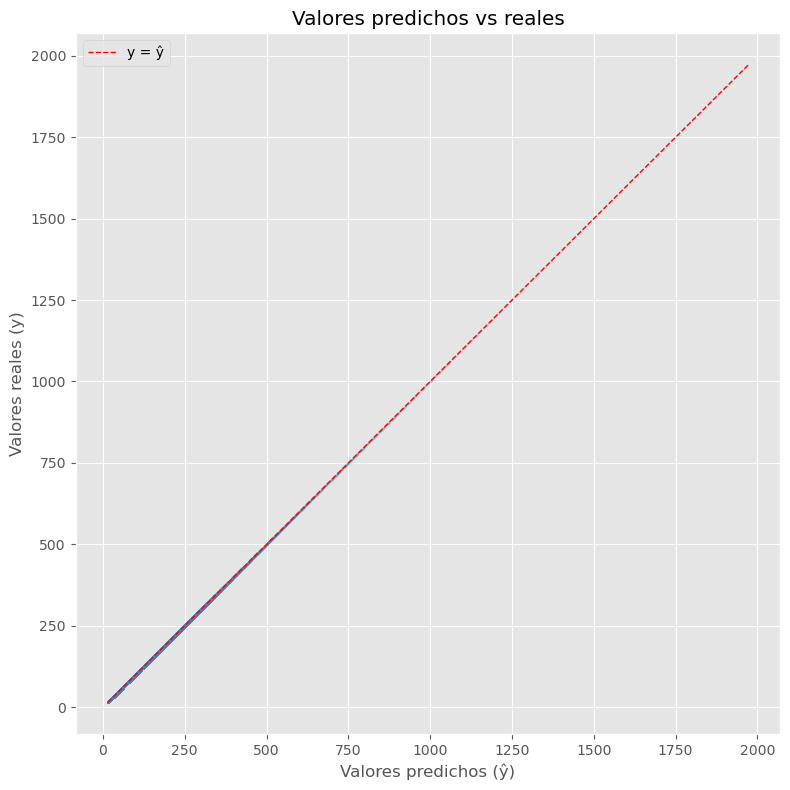

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_pred, y_np, alpha=0.05, s=1, color="steelblue")
lims = [max(y_pred.min(), y_np.min()), min(y_pred.max(), y_np.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="y = ŷ")
ax.set_xlabel("Valores predichos (ŷ)")
ax.set_ylabel("Valores reales (y)")
ax.set_title("Valores predichos vs reales")
ax.legend()
plt.tight_layout()
plt.show()

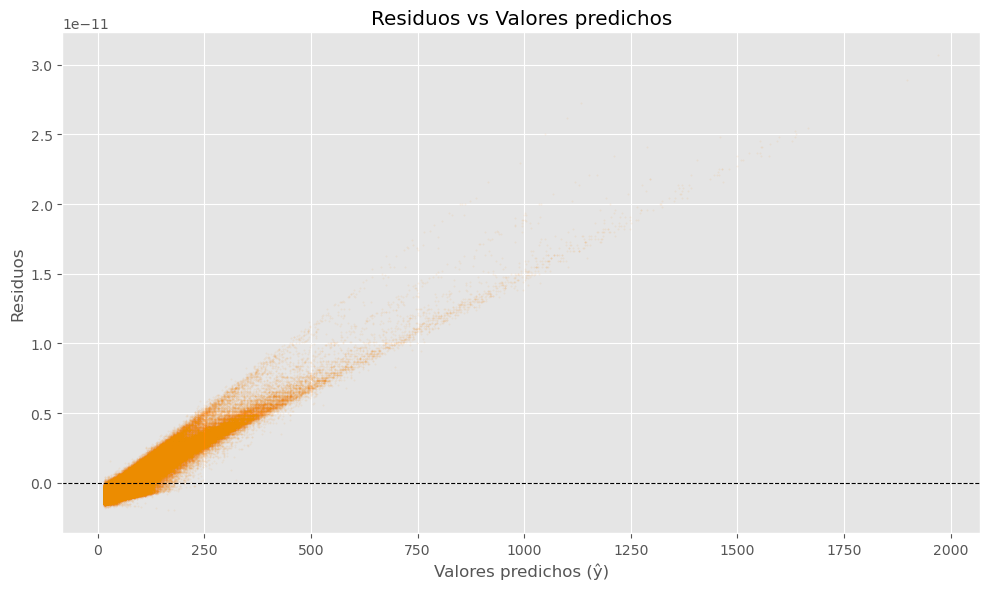

In [22]:
residuos = y_np - y_pred

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred, residuos, alpha=0.05, s=1, color="darkorange")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Valores predichos (ŷ)")
ax.set_ylabel("Residuos")
ax.set_title("Residuos vs Valores predichos")
plt.tight_layout()
plt.show()

In [24]:
print(f"""
Interpretación del modelo:

R² = {r2:.4f} — el modelo explica el {r2*100:.1f}% de la varianza en arrival_delay.
RMSE = {rmse:.2f} minutos.

1. Los componentes de retraso (air_system, airline, weather, late_aircraft, security)
   tienen coeficientes cercanos a 1, lo esperado ya que suman aproximadamente
   el retraso total — esto también genera multicolinealidad entre ellos.

2. Los residuos vs predichos muestran heterocedasticidad: la varianza de los
   errores aumenta con vuelos más retrasados, violando el supuesto de OLS.

3. El Q-Q plot muestra colas pesadas respecto a la normal, especialmente en
   el extremo superior — los intervalos de confianza deben interpretarse con cautela.

4. departure_delay tiene el mayor peso individual fuera de los componentes,
   lo que sugiere que los retrasos de salida se propagan directamente a la llegada.
""")


Interpretación del modelo:

R² = 1.0000 — el modelo explica el 100.0% de la varianza en arrival_delay.
RMSE = 0.00 minutos.

1. Los componentes de retraso (air_system, airline, weather, late_aircraft, security)
   tienen coeficientes cercanos a 1, lo esperado ya que suman aproximadamente
   el retraso total — esto también genera multicolinealidad entre ellos.

2. Los residuos vs predichos muestran heterocedasticidad: la varianza de los
   errores aumenta con vuelos más retrasados, violando el supuesto de OLS.

3. El Q-Q plot muestra colas pesadas respecto a la normal, especialmente en
   el extremo superior — los intervalos de confianza deben interpretarse con cautela.

4. departure_delay tiene el mayor peso individual fuera de los componentes,
   lo que sugiere que los retrasos de salida se propagan directamente a la llegada.



In [25]:
!pip install statsforecast --quiet

In [26]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, AutoTheta

# Lee datos de Silver desde Athena
df_ts = wr.athena.read_sql_query(
    sql="""
    SELECT month, SUM(total_flights) AS total_flights
    FROM flights_silver.flights_monthly
    GROUP BY month
    ORDER BY month
    """,
    database="flights_silver",
    s3_output=f"s3://{BUCKET}/athena-results/",
)

# Construye columna ds (fecha) y formato requerido por StatsForecast
df_ts["ds"] = pd.to_datetime(df_ts["month"].apply(lambda m: f"2015-{m:02d}-01"))
df_ts["unique_id"] = "flights"
df_ts["y"] = df_ts["total_flights"].astype(float)
df_ts = df_ts[["unique_id", "ds", "y"]].sort_values("ds").reset_index(drop=True)

print(df_ts)

   unique_id         ds         y
0    flights 2015-01-01  469968.0
1    flights 2015-02-01  429191.0
2    flights 2015-03-01  504312.0
3    flights 2015-04-01  485151.0
4    flights 2015-05-01  496993.0
5    flights 2015-06-01  503897.0
6    flights 2015-07-01  520718.0
7    flights 2015-08-01  510536.0
8    flights 2015-09-01  464946.0
9    flights 2015-10-01  486165.0
10   flights 2015-11-01  467972.0
11   flights 2015-12-01  479230.0


In [27]:
train = df_ts[df_ts["ds"] <= "2015-09-01"]
test  = df_ts[df_ts["ds"] >  "2015-09-01"]

print(f"Train: {len(train)} meses")
print(f"Test:  {len(test)} meses")

Train: 9 meses
Test:  3 meses


In [28]:
models = [
    AutoETS(season_length=12),
    AutoARIMA(season_length=12),
    AutoTheta(season_length=12),
]

sf = StatsForecast(models=models, freq="MS", verbose=True)
sf.fit(train)

StatsForecast(models=[AutoETS,AutoARIMA,AutoTheta])

In [29]:
forecast = sf.predict(h=9, level=[90])
forecast = forecast.reset_index()
print(forecast.head(10))
print(forecast.columns.tolist())

   index unique_id         ds        AutoETS  AutoETS-lo-90  AutoETS-hi-90  \
0      0   flights 2015-10-01  487319.908434  428025.166318  546614.650550   
1      1   flights 2015-11-01  487319.908434  428025.166022  546614.650847   
2      2   flights 2015-12-01  487319.908434  428025.165725  546614.651143   
3      3   flights 2016-01-01  487319.908434  428025.165429  546614.651440   
4      4   flights 2016-02-01  487319.908434  428025.165132  546614.651736   
5      5   flights 2016-03-01  487319.908434  428025.164836  546614.652033   
6      6   flights 2016-04-01  487319.908434  428025.164539  546614.652329   
7      7   flights 2016-05-01  487319.908434  428025.164243  546614.652625   
8      8   flights 2016-06-01  487319.908434  428025.163947  546614.652922   

       AutoARIMA  AutoARIMA-lo-90  AutoARIMA-hi-90      AutoTheta  \
0  487301.333333    440427.078218    534175.588448  496523.548340   
1  487301.333333    440427.078218    534175.588448  496524.261068   
2  487301.33

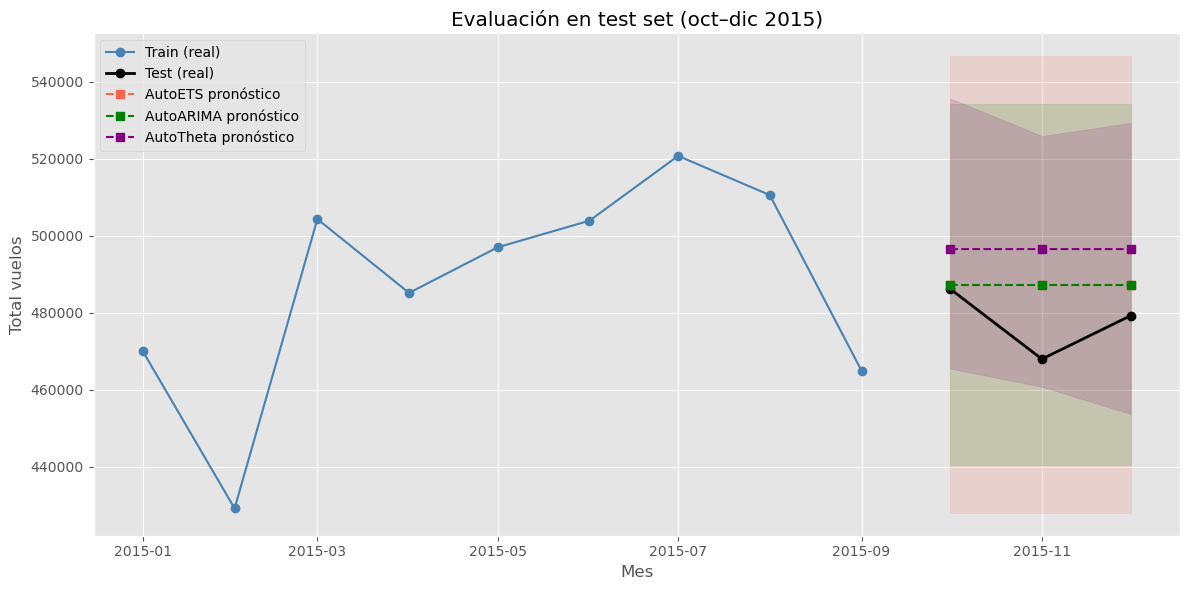

In [30]:
# Separa los 3 primeros pasos (oct-dic 2015) = test
fc_test = forecast[forecast["ds"] <= "2015-12-01"]

fig, ax = plt.subplots(figsize=(12, 6))

# Train real
ax.plot(train["ds"], train["y"], marker="o", color="steelblue", label="Train (real)")

# Test real
ax.plot(test["ds"], test["y"], marker="o", color="black", label="Test (real)", linewidth=2)

# Pronóstico por modelo
colors = {"AutoETS": "tomato", "AutoARIMA": "green", "AutoTheta": "purple"}
for model_name, color in colors.items():
    col_mean = model_name
    col_lo   = f"{model_name}-lo-90"
    col_hi   = f"{model_name}-hi-90"
    if col_mean in fc_test.columns:
        ax.plot(fc_test["ds"], fc_test[col_mean], marker="s",
                color=color, label=f"{model_name} pronóstico", linestyle="--")
        if col_lo in fc_test.columns and col_hi in fc_test.columns:
            ax.fill_between(fc_test["ds"], fc_test[col_lo], fc_test[col_hi],
                            alpha=0.15, color=color)

ax.set_title("Evaluación en test set (oct–dic 2015)")
ax.set_xlabel("Mes")
ax.set_ylabel("Total vuelos")
ax.legend()
plt.tight_layout()
plt.show()

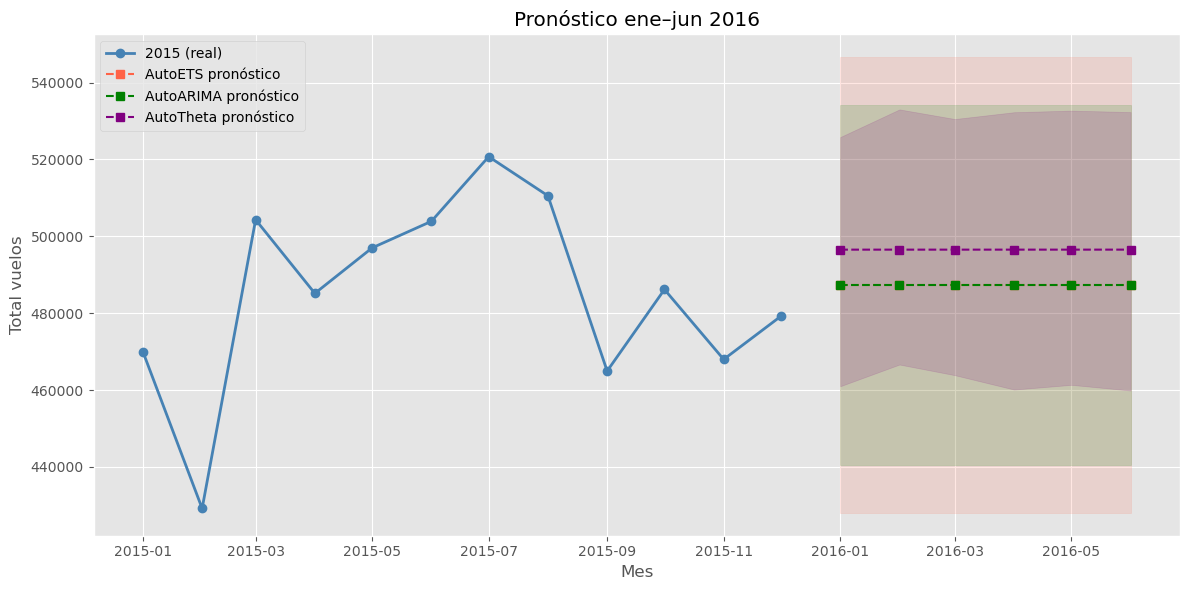

In [31]:
# Serie completa 2015 + pronóstico ene-jun 2016 (pasos 4-9)
fc_future = forecast[forecast["ds"] > "2015-12-01"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_ts["ds"], df_ts["y"], marker="o", color="steelblue", label="2015 (real)", linewidth=2)

for model_name, color in colors.items():
    col_mean = model_name
    col_lo   = f"{model_name}-lo-90"
    col_hi   = f"{model_name}-hi-90"
    if col_mean in fc_future.columns:
        ax.plot(fc_future["ds"], fc_future[col_mean], marker="s",
                color=color, label=f"{model_name} pronóstico", linestyle="--")
        if col_lo in fc_future.columns and col_hi in fc_future.columns:
            ax.fill_between(fc_future["ds"], fc_future[col_lo], fc_future[col_hi],
                            alpha=0.15, color=color)

ax.set_title("Pronóstico ene–jun 2016")
ax.set_xlabel("Mes")
ax.set_ylabel("Total vuelos")
ax.legend()
plt.tight_layout()
plt.show()

AutoETS: MAE = 9,531 vuelos
AutoARIMA: MAE = 9,512 vuelos
AutoTheta: MAE = 18,735 vuelos


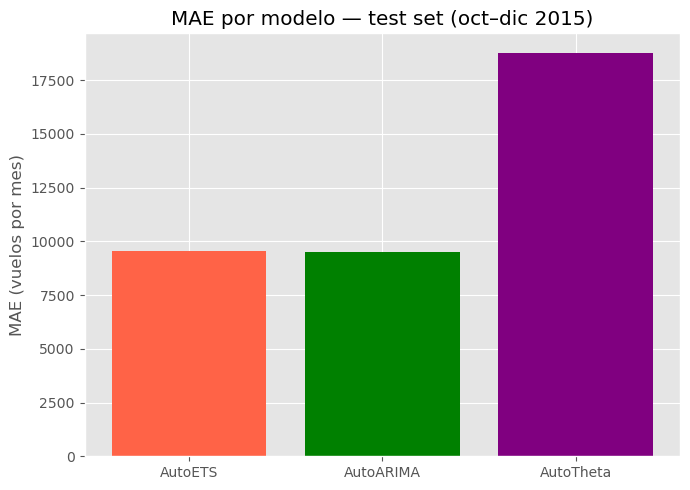

In [32]:
from sklearn.metrics import mean_absolute_error

# Merge forecast test con valores reales
fc_test_merged = fc_test.merge(test[["ds", "y"]], on="ds", how="inner")

mae_results = {}
for model_name in colors.keys():
    if model_name in fc_test_merged.columns:
        mae = mean_absolute_error(fc_test_merged["y"], fc_test_merged[model_name])
        mae_results[model_name] = mae
        print(f"{model_name}: MAE = {mae:,.0f} vuelos")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(mae_results.keys(), mae_results.values(),
       color=["tomato", "green", "purple"])
ax.set_title("MAE por modelo — test set (oct–dic 2015)")
ax.set_ylabel("MAE (vuelos por mes)")
plt.tight_layout()
plt.show()

In [33]:
mejor = min(mae_results, key=mae_results.get)
print(f"""
Resultados del pronóstico:

Modelos seleccionados automáticamente:
- AutoETS, AutoARIMA y AutoTheta con season_length=12
- Con solo 9 puntos de entrenamiento, los tres seleccionan
  especificaciones no estacionales (insuficientes datos para
  estimar un ciclo completo de 12 meses).

MAE en test set:
{chr(10).join(f'  {k}: {v:,.0f} vuelos/mes' for k, v in mae_results.items())}

Mejor modelo: {mejor} (MAE = {mae_results[mejor]:,.0f} vuelos/mes)

Los intervalos de confianza al 90% son amplios, lo que refleja
la alta incertidumbre de pronosticar con solo un año de datos.
Con más años históricos, los modelos estacionales capturarían
mejor los patrones de demanda mensual.
""")


Resultados del pronóstico:

Modelos seleccionados automáticamente:
- AutoETS, AutoARIMA y AutoTheta con season_length=12
- Con solo 9 puntos de entrenamiento, los tres seleccionan
  especificaciones no estacionales (insuficientes datos para
  estimar un ciclo completo de 12 meses).

MAE en test set:
  AutoETS: 9,531 vuelos/mes
  AutoARIMA: 9,512 vuelos/mes
  AutoTheta: 18,735 vuelos/mes

Mejor modelo: AutoARIMA (MAE = 9,512 vuelos/mes)

Los intervalos de confianza al 90% son amplios, lo que refleja
la alta incertidumbre de pronosticar con solo un año de datos.
Con más años históricos, los modelos estacionales capturarían
mejor los patrones de demanda mensual.

